# 🧪 5.4 Validación Externa de Modelos — Gated Pooling + AAontology: MLP vs CNN vs BiLSTM

Este notebook realiza la validación externa de los mejores checkpoints obtenidos con arquitecturas basadas en **Gated Pooling + AAontology**. El objetivo es evaluar si los modelos **MLP_Small**, **CNN_Medium** y **BiLSTM_Small** generalizan correctamente sobre un conjunto de prueba independiente, más allá de los resultados de validación utilizados durante el entrenamiento.

En esta etapa no se entrenan nuevos pesos: se cargan los modelos finales, se reconstruyen sus arquitecturas y se evalúan con las mismas entradas utilizadas en los notebooks anteriores.

---

## 📋 Descripción general

El conjunto de prueba contiene **15,685 muestras**, con **4,914 positivas** y **10,771 negativas**, lo que corresponde a una relación aproximada de **0.46**. Cada muestra se representa mediante:

- `X`: embeddings por residuo de ProtFlash, con forma `(B, L, 768)`.
- `Ont`: perfiles AAontology por residuo, con forma `(B, L, 8)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

Durante la evaluación:

1. Se cargan los checkpoints de:
   - `MLP_Small`
   - `CNN_Medium`
   - `BiLSTM_Small`
2. Se reconstruyen las arquitecturas correspondientes:
   - `AAontologyMLPClassifier`
   - `GatedConv1DClassifier`
   - `AAontologyBiLSTMClassifier`
3. Cada modelo procesa `X`, `Ont` y `M` para generar probabilidades de clasificación.
4. Se aplica un umbral de `0.5` y se calculan las métricas finales sobre el conjunto de prueba.

---

## 🛠️ Funcionalidades principales

1. **Carga y reconstrucción de modelos**
   - Importación de los checkpoints finales entrenados con Gated Pooling + AAontology.
   - Reconstrucción de cada arquitectura usando la configuración guardada en el checkpoint.

2. **Evaluación externa**
   - Inferencia sobre el conjunto de prueba sin reentrenamiento.
   - Uso de `AAontologyGatedPooler` y representaciones combinadas de ProtFlash + AAontology.
   - Cálculo de:
     - Accuracy
     - Precision
     - Recall
     - F1-score
     - MCC
     - ROC-AUC
     - PR-AUC
     - Matriz de confusión

3. **Comparación de generalización**
   - Ranking de modelos por **Test MCC**.
   - Comparación entre métricas de validación y métricas de test.
   - Detección de posible sobreajuste mediante la brecha Val/Test.

4. **Visualización y exportación**
   - Gráficos de barras comparativos.
   - Curvas ROC.
   - Curvas de precisión-recall.
   - Matrices de confusión.
   - Exportación de resultados en CSV y JSON dentro de `Validation_Results/`.

## 📦 Importación de librerías y entorno

In [1]:
import os
import random
from pathlib import Path
from typing import Any, Dict, List, Tuple
import json

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, roc_curve, precision_recall_curve, auc,
    confusion_matrix
)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

print("torch:", torch.__version__)

torch: 2.10.0+cu128


## ⚙️ Configuración de rutas e hiperparámetros de evaluación

In [2]:
MLP_DIR = Path("/kaggle/input/datasets/user/otro-gated-aaontology-mlp/MLP_Results")
CNN_DIR = Path("/kaggle/input/datasets/user/otro-gated-aaontology-cnn")
LSTM_DIR = Path("/kaggle/input/datasets/user/otro-gated-aaontology-lstm")

EVAL_DIR    = Path("/kaggle/working/Validation_Results")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TEST_PT     = Path("/kaggle/input/datasets/user/new-final-dataset/test_dataset.pt")
AAONTOLOGY_PATH = Path("/kaggle/input/datasets/user/new-aaontology/AAontology_zscored.pt")

# Checkpoints a evaluar
CHECKPOINTS = {
    "MLP_Small":    MLP_DIR / "best_model_final.pth",
    "CNN_Medium":     CNN_DIR / "best_model_final.pth",
    "BiLSTM_Small": LSTM_DIR / "best_model_final.pth",
}

SEED        = 31
BATCH_SIZE  = 32
L_MAX       = 100
INPUT_DIM   = 768    
THRESHOLD = 0.5

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 🔬 Carga del tensor AAontology

In [4]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]       # (21, 8)
    AA_ORDER = aa_data["amino_acids"]            # ['A', ..., 'Y', 'X']
    USED_CATEGORIES = aa_data["categories"]      # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_CAT = AAONTOLOGY_ZSCORED.shape[1]

print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 📂 Definición de la clase `AMPDataset`

In [5]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.seqs) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }

## 🔑 Función para construir perfiles AAontology por batch

In [6]:
def build_ontology_profiles(seqs, B, L, dtype=torch.float32):
    """
    Construye Ont: (B, L, N_CAT) a partir de secuencias.
    Usa la fila 'X' para padding / aminoácidos desconocidos.
    """
    x_idx = AA_TO_IDX.get("X", AAONTOLOGY_ZSCORED.shape[0] - 1)

    aa_indices = torch.full((B, L), x_idx, dtype=torch.long)

    for i, seq in enumerate(seqs):
        if not seq:
            continue

        for j, aa in enumerate(seq[:L]):
            aa_indices[i, j] = AA_TO_IDX.get(aa, x_idx)

    return AAONTOLOGY_ZSCORED[aa_indices].to(dtype=dtype)

## 💾 Función de carga de datasets pre-serializados

In [7]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de prueba

In [8]:
print("Loading test dataset:")
test_ds = load_pt_dataset(TEST_PT)

pos = int(test_ds.y.sum().item())
neg = test_ds.y.shape[0] - pos
total = test_ds.y.shape[0]
print(f"Test set: total={len(test_ds.y)}, pos={pos}, neg={neg}, pos_ratio={pos/len(test_ds.y):.3f}")

Loading test dataset:
Test set: total=15685, pos=4914, neg=10771, pos_ratio=0.313


## 🤝 Función de colación (`collate_fn`)

In [9]:
def collate_fn_aaontology(batch):
    """
    Devuelve:
      X:   (B, L, 768)
      Ont: (B, L, 8)
      M:   (B, L)
      seqs: List[str]
      y:   (B, 1)
    """

    X = torch.stack([item["X"] for item in batch], dim=0)
    M = torch.stack([item["M"] for item in batch], dim=0)
    y = torch.stack([item["y"] for item in batch], dim=0)

    seqs = [item.get("seq", "") for item in batch]

    first = batch[0]

    # Caso 1: el dataset ya trae Ont precomputado.
    if "Ont" in first and first["Ont"] is not None:
        Ont = torch.stack([item["Ont"] for item in batch], dim=0).to(X.dtype)

    # Caso 2: el dataset trae G como ontología por residuo (B/L, 8).
    elif (
        "G" in first
        and isinstance(first["G"], torch.Tensor)
        and first["G"].dim() == 2
        and first["G"].size(-1) == N_CAT
    ):
        Ont = torch.stack([item["G"] for item in batch], dim=0).to(X.dtype)

    # Caso 3: construir Ont desde la secuencia.
    else:
        B, L, _ = X.shape
        Ont = build_ontology_profiles(seqs, B, L, dtype=X.dtype)

    return X, Ont, M, seqs, y

## 🚚 Creación de DataLoader

In [10]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_aaontology)

print(f"✅ Dataset listo: {len(test_ds)} muestras")
print(f"   Ejemplo de batch: {[t.shape if isinstance(t, torch.Tensor) else type(t).__name__ for t in test_ds[0]]}")

X_b, Ont_b, M_b, seq_b, y_b = next(iter(test_loader))
print("X:", X_b.shape)     # (B, L, 768)
print("Ont:", Ont_b.shape) # (B, L, 8)
print("M:", M_b.shape)     # (B, L)
print("y:", y_b.shape)     # (B, 1)
print("seqs:", len(seq_b))

✅ Dataset listo: 15685 muestras
   Ejemplo de batch: ['str', 'str', 'str', 'str', 'str']
X: torch.Size([32, 100, 768])
Ont: torch.Size([32, 100, 8])
M: torch.Size([32, 100])
y: torch.Size([32, 1])
seqs: 32


## 🧩 Capa `AAontologyGatedPooler` diferenciable

In [11]:
class AAontologyGatedPooler(nn.Module):
    """
    Gated Pooling guiado por AAontology.

    Input:
      X:   (B, L, input_dim)  # ProtFlash por residuo
      Ont: (B, L, n_categories)  # AAontology por residuo
      M:   (B, L)

    Output:
      E_local: (B, input_dim)
    """

    def __init__(
        self,
        input_dim: int = 768,
        n_categories: int = 8,
        ont_hidden: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.ont_proj = nn.Linear(n_categories, ont_hidden)

        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim + ont_hidden, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

        self.proj = nn.Linear(input_dim, input_dim)

    def _raw_gates(self, X, Ont, M):
        ont_proj = self.ont_proj(Ont)  # (B, L, ont_hidden)

        combined = torch.cat([X, ont_proj], dim=-1)  # (B, L, input_dim + ont_hidden)

        gates = self.gating_mlp(combined)  # (B, L, 1)
        gates = gates * M.unsqueeze(-1)

        return gates

    def forward(self, X, Ont, M):
        gates = self._raw_gates(X, Ont, M)  # (B, L, 1)

        weighted = gates * self.proj(X) * M.unsqueeze(-1)

        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)

        return weighted.sum(dim=1) / denom

    def get_gates(self, X, Ont, M):
        """
        Devuelve gates por residuo:
          (B, L)
        """
        return self._raw_gates(X, Ont, M).squeeze(-1)

## 🧩 Definición de arquitecturas gated para reconstrucción de checkpoints

In [12]:
# --- Gated MLP ---
class AAontologyMLPClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_dims: List[int],
        dropout: float = 0.3,
        pooling: str = "gated",
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooling = pooling

        if pooling == "gated":
            self.pooler = AAontologyGatedPooler(
                input_dim=input_dim,
                n_categories=n_categories,
                dropout=0.1,
            )
        else:
            raise ValueError("pooling debe ser 'gated'")

        # E_local + E_global
        in_features = input_dim * 2

        layers = []

        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def _global_pool(self, X, M):
        """
        X: (B, L, D)
        M: (B, L)
        """
        M = M.unsqueeze(-1).float()  # (B, L, 1)

        # Evitar división por cero si alguna máscara está vacía
        lengths = M.sum(dim=1).clamp(min=1e-8)  # (B, 1)

        # Masked mean pooling
        E_global = (X * M).sum(dim=1) / lengths  # (B, D)

        return E_global

    def forward(self, X, Ont, M):
        """
        X:   (B, L, 768)
        Ont: (B, L, 8)
        M:   (B, L)
        """

        # Representación local guiada por AAontology
        E_local = self.pooler(X, Ont, M)  # (B, 768)

        # Representación global de la secuencia
        E_global = self._global_pool(X, M)  # (B, 768)

        # Concatenación E_local + E_global
        x = torch.cat([E_local, E_global], dim=-1)  # (B, 1536)

        x = self.mlp_body(x)

        return self.classifier(x)

    def get_gates(self, X, Ont, M):
        if self.pooling == "gated":
            return self.pooler.get_gates(X, Ont, M)

def build_aaontology_mlp_model(config: Dict, input_dim: int) -> nn.Module:
    return AAontologyMLPClassifier(
        input_dim=input_dim,
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"],
        pooling=config.get("pooling", "gated"),
        n_categories=N_CAT,
    )

# --- Gated CNN ---
class GatedConv1DClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        conv_channels: List[int],
        kernel_sizes: List[int],
        mlp_hidden: List[int],
        dropout: float = 0.3,
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooler = AAontologyGatedPooler(
            input_dim=input_dim,
            n_categories=n_categories
        )

        self.convs = nn.ModuleList()
        in_channels = input_dim

        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(nn.Sequential(
                nn.Conv1d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=k_size,
                    padding="same",
                ),
                nn.BatchNorm1d(out_channels),
                nn.GELU(),
                nn.Dropout1d(dropout),
            ))
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool

        # cnn_features + E_local (sin E_global)
        clf_in_dim = cnn_out_dim + input_dim

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X, Ont, M):
        E_local = self.pooler(X, Ont, M)  # (B, 768)

        x_cnn = X.transpose(1, 2)  # (B, D, L)

        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()

        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        # Solo cnn_features + E_local
        combined = torch.cat([cnn_features, E_local], dim=1)

        x = self.mlp(combined)
        return self.classifier(x)

    def get_gates(self, X, Ont, M):
        return self.pooler.get_gates(X, Ont, M)


def build_gated_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedConv1DClassifier(
        input_dim=input_dim,
        conv_channels=config["conv_channels"],
        kernel_sizes=config["kernel_sizes"],
        mlp_hidden=config["mlp_hidden"],
        dropout=config["dropout"],
        n_categories=N_CAT,
    )
    

# --- Gated BiLSTM ---
class AAontologyBiLSTMClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_size: int,
        num_layers: int,
        mlp_hidden: List[int],
        dropout: float = 0.3,
        pooling: str = "gated",
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooling = pooling

        if pooling == "gated":
            self.pooler = AAontologyGatedPooler(
                input_dim=input_dim,
                n_categories=n_categories,
                dropout=0.1,
            )
        else:
            raise ValueError("pooling debe ser 'gated'")

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # max_pool + avg_pool sobre salida bidireccional
        lstm_out_dim = hidden_size * 4

        # lstm_features + E_local + E_global
        clf_in_dim = lstm_out_dim + input_dim * 2

        layers = []

        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X, Ont, M):
        """
        X:   (B, L, 768)
        Ont: (B, L, 8)
        M:   (B, L)
        """

        E_global = self.pooler(X, Ont, M)  # (B, 768)

        if self.pooling == "gated":
            # Gates guiados por ProtFlash + AAontology
            gates = self.pooler.get_gates(X, Ont, M)  # (B, L)
            gates = gates.unsqueeze(-1)               # (B, L, 1)

            # Secuencia ponderada por gates
            seq_input = X * gates

            # Representación local pooled
            E_local = self.pooler(X, Ont, M)

        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            seq_input,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        packed_out, _ = self.lstm(packed)

        lstm_out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=X.size(1),
        )

        # Pooling sobre salida LSTM
        mask = M.unsqueeze(-1).bool()  # (B, L, 1)

        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]

        avg_pool = (
            lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
            / M.sum(dim=1, keepdim=True).clamp(min=1e-8)
        )

        lstm_features = torch.cat([max_pool, avg_pool], dim=1)

        combined = torch.cat(
            [
                lstm_features,
                E_local,
                E_global,
            ],
            dim=1,
        )

        x = self.mlp(combined)

        return self.classifier(x)


def build_aaontology_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return AAontologyBiLSTMClassifier(
        input_dim=input_dim,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        mlp_hidden=config["mlp_hidden"],
        dropout=config["dropout"],
        pooling=config.get("pooling", "gated"),
        n_categories=N_CAT,
    )

## 📥 Carga segura de checkpoints y verificación de metadatos

In [13]:
def load_model(path, model_class, device, input_dim):
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    config = ckpt.get("config", {})
    input_dim = ckpt.get("input_dim", input_dim)

    if model_class == AAontologyMLPClassifier:
        model = AAontologyMLPClassifier(
            input_dim=input_dim,
            hidden_dims=config["hidden_dims"],
            dropout=config.get("dropout", 0.3),
            n_categories=N_CAT,
        )

    elif model_class == GatedConv1DClassifier:
        model = GatedConv1DClassifier(
            input_dim=input_dim,
            conv_channels=config["conv_channels"],
            kernel_sizes=config["kernel_sizes"],
            mlp_hidden=config["mlp_hidden"],
            dropout=config.get("dropout", 0.3),
            n_categories=N_CAT,
        )

    elif model_class == AAontologyBiLSTMClassifier:
        model = AAontologyBiLSTMClassifier(
            input_dim=input_dim,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            mlp_hidden=config["mlp_hidden"],
            dropout=config.get("dropout", 0.3),
            n_categories=N_CAT,
        )

    else:
        raise ValueError(f"Clase desconocida: {model_class}")

    model.load_state_dict(ckpt["state_dict"])
    return model.to(device).eval()

print("Cargando checkpoints...")
model_mlp = load_model(CHECKPOINTS["MLP_Small"], AAontologyMLPClassifier, DEVICE, INPUT_DIM)
model_cnn  = load_model(CHECKPOINTS["CNN_Medium"],  GatedConv1DClassifier, DEVICE, INPUT_DIM)
model_bilstm = load_model(CHECKPOINTS["BiLSTM_Small"], AAontologyBiLSTMClassifier, DEVICE, INPUT_DIM)
print("✅ Modelos cargados exitosamente.")

Cargando checkpoints...
✅ Modelos cargados exitosamente.


## 📐 Helper: `sigmoid_np`

In [14]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [15]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    logits_list, y_list = [], []
    for Xb, Ontb, Mb, seqs, yb in loader:
        logits = model(Xb.to(device), Ontb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    return sigmoid_np(np.concatenate(logits_list)), np.concatenate(y_list)

## 📏 Cálculo de Métricas de Clasificación

In [16]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [17]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento & Evaluación

In [18]:
all_eval: List[Dict[str, Any]] = []

print("\n" + "=" * 90)
print("EVALUATING GATED MODELS ON TEST SET")
print("=" * 90)

for model_name, ckpt_path in CHECKPOINTS.items():
    print(f"\n{'─' * 80}")

    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)

    config = ckpt["config"]
    input_dim = ckpt["input_dim"]
    n_params = ckpt.get("n_params", 0)
    best_epoch = ckpt.get("best_epoch", None)
    best_val_loss = ckpt.get("best_val_loss", None)
    val_metrics = ckpt.get("val_metrics", {})

    print(f"Model: {model_name}")
    print(f"  Parameters: {n_params:,}")
    print(f"  Best training epoch: {best_epoch if best_epoch is not None else '?'}")
    print(f"  Best val loss: {best_val_loss if best_val_loss is not None else '?'}")
    if val_metrics:
        print(f"  Val Acc: {val_metrics.get('accuracy', 'N/A')}")
        print(f"  Val F1:  {val_metrics.get('f1', 'N/A')}")

    # Build & load model
    if "MLP" in model_name:
        model = build_aaontology_mlp_model(config, input_dim)
    elif "CNN" in model_name or "Conv" in model_name:
        model = build_gated_cnn_model(config, input_dim)
    else:
        model = build_aaontology_lstm_model(config, input_dim)

    model.load_state_dict(ckpt["state_dict"])
    model.to(DEVICE)
    model.eval()

    # Predict on test
    y_prob, y_true = predict_proba(model, test_loader, DEVICE)
    metrics = compute_metrics(y_true, y_prob)

    # Curvas
    fpr, tpr, _ = roc_curve(y_true.astype(int), y_prob)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true.astype(int), y_prob)

    entry = {
        "name": model_name,
        "config": config,
        "n_params": n_params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "val_metrics": val_metrics,  
        "test_metrics": metrics,
        "y_prob": y_prob,
        "y_true": y_true,
        "fpr": fpr,
        "tpr": tpr,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
    }

    cm = confusion_matrix(y_true.astype(int), (y_prob >= THRESHOLD).astype(int), labels=[0, 1])
    entry["test_metrics"]["confusion_matrix"] = {"tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1])}
    
    all_eval.append(entry)

    print(f"  ✅ Test Acc={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f} | "
          f"MCC={metrics['mcc']:.4f} | AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f}")

print(f"\n{'=' * 90}")
print(f"Evaluated {len(all_eval)} gated models on test")
print("=" * 90)


EVALUATING GATED MODELS ON TEST SET

────────────────────────────────────────────────────────────────────────────────
Model: MLP_Small
  Parameters: 1,125,442
  Best training epoch: 6
  Best val loss: 0.04792770045961058
  Val Acc: 0.8992248062015504
  Val F1:  0.8852097130242825
  ✅ Test Acc=0.9142 | F1=0.8663 | MCC=0.8037 | AUC=0.9600 | PR-AUC=0.9445

────────────────────────────────────────────────────────────────────────────────
Model: CNN_Medium
  Parameters: 1,584,578
  Best training epoch: 7
  Best val loss: 0.047899398765014124
  Val Acc: 0.9035852713178295
  Val F1:  0.893525949705725
  ✅ Test Acc=0.9010 | F1=0.8512 | MCC=0.7803 | AUC=0.9499 | PR-AUC=0.9345

────────────────────────────────────────────────────────────────────────────────
Model: BiLSTM_Small
  Parameters: 1,880,386
  Best training epoch: 5
  Best val loss: 0.04884186005147621
  Val Acc: 0.8992248062015504
  Val F1:  0.8866485013623978
  ✅ Test Acc=0.9075 | F1=0.8568 | MCC=0.7894 | AUC=0.9572 | PR-AUC=0.9406

E

## 📊 Tabla Resumen y Ranking de Modelos

In [19]:
rows = []
for r in all_eval:
    m = r["test_metrics"]
    vm = r.get("val_metrics", {})
    rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Train Epoch": r.get("best_epoch"),  
        "Val Loss": r.get("best_val_loss"),  
        "Val Acc ": vm.get("accuracy"),
        "Val F1 ": vm.get("f1"),
        "Test Acc": m["accuracy"],
        "Test Prec": m["precision"],
        "Test Recall": m["recall"],
        "Test F1": m["f1"],
        "Test MCC": m["mcc"],
        "Test ROC-AUC": m["roc_auc"],
        "Test PR-AUC": m["pr_auc"],
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Test MCC", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

print("\n" + "=" * 120)
print("TEST SET — GATED MODEL COMPARISON (sorted by Test MCC)")
print("=" * 120)
print(results_df.to_string())
print("=" * 120)

csv_path = EVAL_DIR / "test_comparison_table.csv"
results_df.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

best_name = results_df.iloc[0]["Model"]
best_entry = next(r for r in all_eval if r["name"] == best_name)
print(f"\n🏆 Best gated model on test: {best_name}")


TEST SET — GATED MODEL COMPARISON (sorted by Test MCC)
             Model   Params  Train Epoch  Val Loss  Val Acc    Val F1   Test Acc  Test Prec  Test Recall   Test F1  Test MCC  Test ROC-AUC  Test PR-AUC
Rank                                                                                                                                                   
1        MLP_Small  1125442            6  0.047928  0.899225  0.885210  0.914249   0.846976     0.886447  0.866262  0.803655      0.960039     0.944521
2     BiLSTM_Small  1880386            5  0.048842  0.899225  0.886649  0.907491   0.831769     0.883394  0.856805  0.789352      0.957195     0.940624
3       CNN_Medium  1584578            7  0.047899  0.903585  0.893526  0.900988   0.804383     0.903744  0.851174  0.780327      0.949938     0.934459

Saved: /kaggle/working/Validation_Results/test_comparison_table.csv

🏆 Best gated model on test: MLP_Small


## 🔍 Análisis de gap: Validación vs Test

In [20]:
print("\n" + "=" * 100)
print("VALIDATION vs TEST — PERFORMANCE GAP")
print("=" * 100)

gap_rows = []
for r in all_eval:
    vm = r.get("val_metrics", {})
    tm = r["test_metrics"]
    gap_rows.append({
        "Model": r["name"],
        "Val Acc": vm.get("accuracy"),
        "Test Acc": tm["accuracy"],
        "Δ Acc": (tm["accuracy"] - vm.get("accuracy", 0)) if vm.get("accuracy") is not None else None,
        "Val F1": vm.get("f1"),
        "Test F1": tm["f1"],
        "Δ F1": (tm["f1"] - vm.get("f1", 0)) if vm.get("f1") is not None else None,
        "Val MCC": vm.get("mcc"),
        "Test MCC": tm["mcc"],
        "Δ MCC": (tm["mcc"] - vm.get("mcc", 0)) if vm.get("mcc") is not None else None,
        "Val AUC": vm.get("roc_auc"),
        "Test AUC": tm["roc_auc"],
        "Δ AUC": (tm["roc_auc"] - vm.get("roc_auc", 0)) if vm.get("roc_auc") is not None else None,
    })

gap_df = pd.DataFrame(gap_rows)
print(gap_df.to_string(index=False))

gap_csv = EVAL_DIR / "val_vs_test_gap.csv"
gap_df.to_csv(gap_csv, index=False)
print(f"\nSaved: {gap_csv}")


VALIDATION vs TEST — PERFORMANCE GAP
       Model  Val Acc  Test Acc     Δ Acc   Val F1  Test F1      Δ F1  Val MCC  Test MCC     Δ MCC  Val AUC  Test AUC     Δ AUC
   MLP_Small 0.899225  0.914249  0.015024 0.885210 0.866262 -0.018947 0.802421  0.803655  0.001234 0.958366  0.960039  0.001672
  CNN_Medium 0.903585  0.900988 -0.002597 0.893526 0.851174 -0.042352 0.807549  0.780327 -0.027221 0.961105  0.949938 -0.011168
BiLSTM_Small 0.899225  0.907491  0.008266 0.886649 0.856805 -0.029844 0.800618  0.789352 -0.011266 0.956995  0.957195  0.000200

Saved: /kaggle/working/Validation_Results/val_vs_test_gap.csv


## 📈 Visualización: Gráfico de barras comparativo por métrica

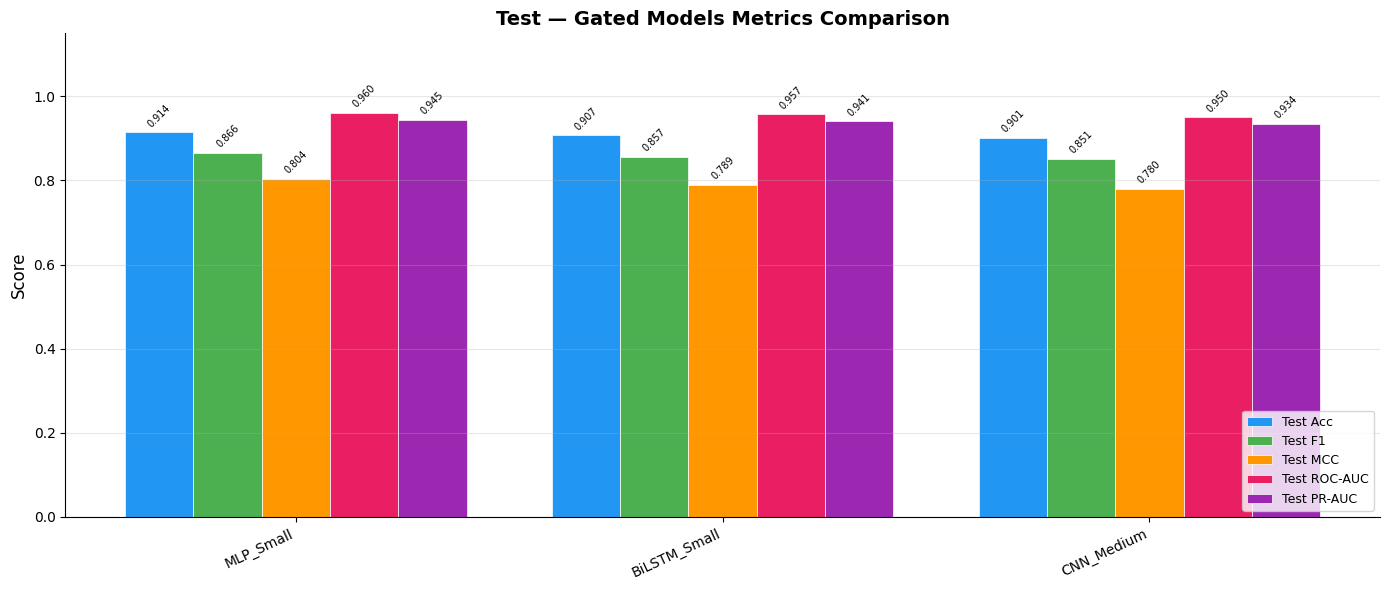

Saved: /kaggle/working/Validation_Results/test_metrics_bar_chart.png


In [21]:
metric_cols = ["Test Acc", "Test F1", "Test MCC", "Test ROC-AUC", "Test PR-AUC"]
models = results_df["Model"].values

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(models))
n_metrics = len(metric_cols)
width = 0.8 / n_metrics
colors_bar = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"]

for j, (col, color) in enumerate(zip(metric_cols, colors_bar)):
    vals = results_df[col].values.astype(float)
    bars = ax.bar(x + j * width, vals, width, label=col, color=color, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x + width * (n_metrics - 1) / 2)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test — Gated Models Metrics Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(EVAL_DIR / "test_metrics_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'test_metrics_bar_chart.png'}")

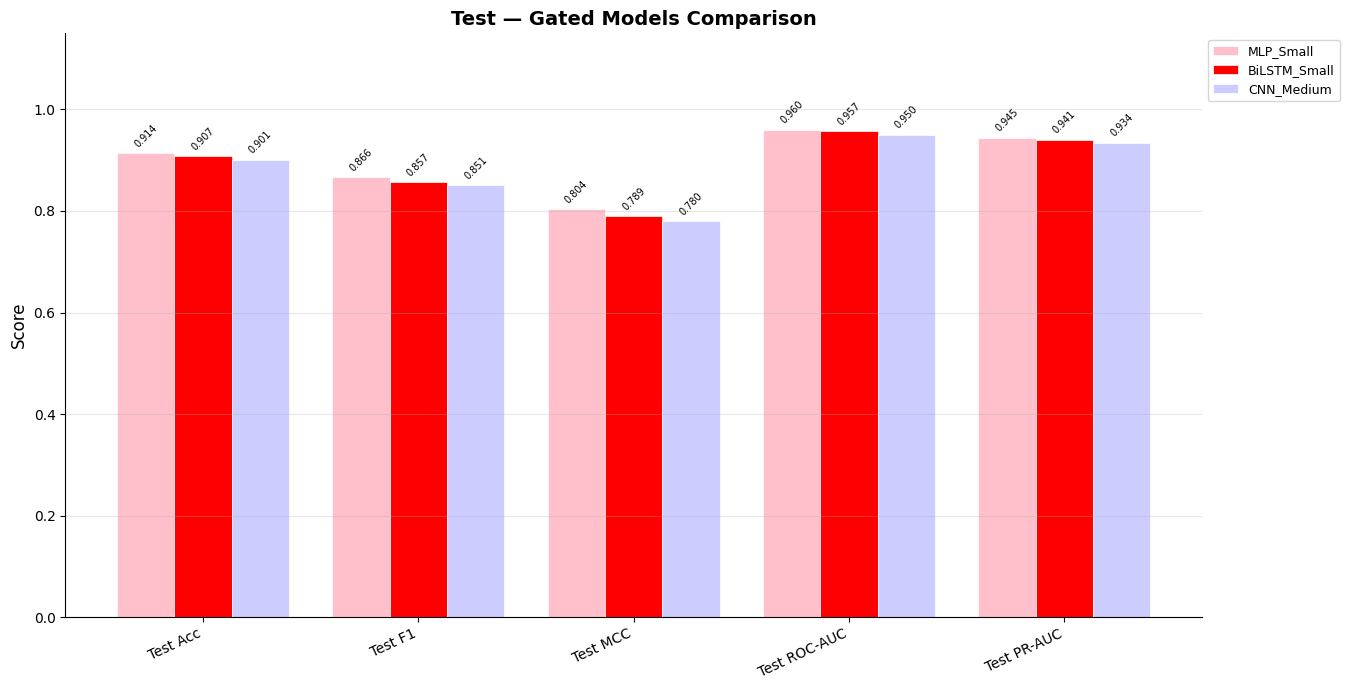

Saved: /kaggle/working/Validation_Results/test_metrics_bar_chart_transposed.png


In [22]:
metric_cols_plot = ["Test Acc", "Test F1", "Test MCC", "Test ROC-AUC", "Test PR-AUC"]
model_names = results_df["Model"].values

fig, ax = plt.subplots(figsize=(16, 7))
x_pos_metrics = np.arange(len(metric_cols_plot))
n_models = len(model_names)
width = 0.8 / n_models
colors_model = ["#FFC0CB", "#FF0000", "#CCCCFF"]

for i, model_name in enumerate(model_names):
    vals = results_df[results_df["Model"] == model_name][metric_cols_plot].values.flatten().astype(float)
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x_pos_metrics + offset, vals, width,
                  label=model_name, color=colors_model[i % len(colors_model)], edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x_pos_metrics)
ax.set_xticklabels(metric_cols_plot, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test — Gated Models Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1,1), fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(rect=[0, 0, 0.85, 1])
fig.savefig(EVAL_DIR / "test_metrics_bar_chart_transposed.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'test_metrics_bar_chart_transposed.png'}")

## 📈 Visualización: Curvas ROC

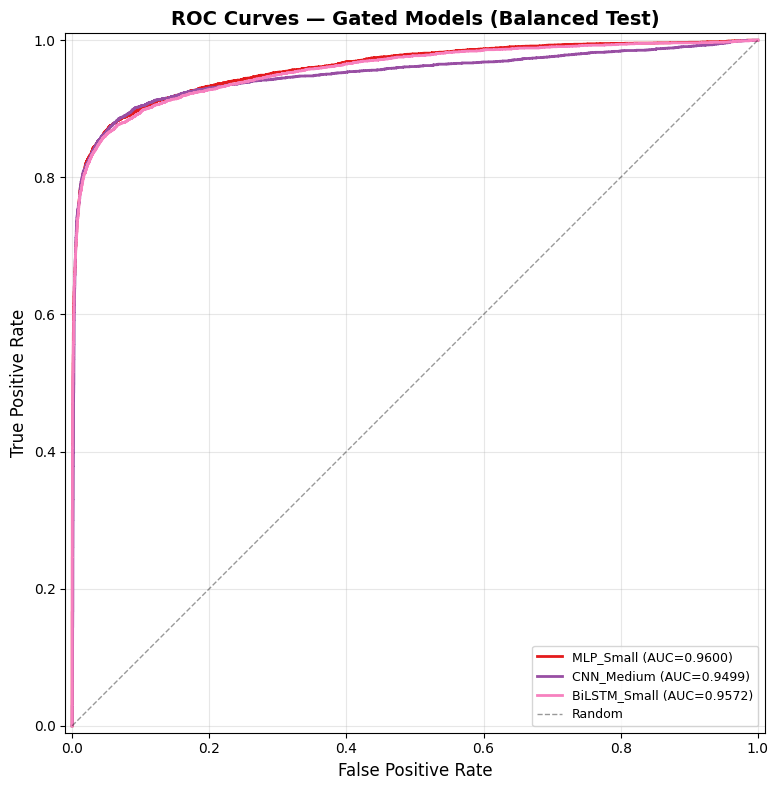

Saved: /kaggle/working/Validation_Results/roc_curves_comparison.png


In [23]:
# ========== CURVAS ROC ==========
fig, ax = plt.subplots(figsize=(8, 8))
colors_line = plt.cm.Set1(np.linspace(0, 0.8, len(all_eval)))

for idx, r in enumerate(all_eval):
    auc_val = r["test_metrics"]["roc_auc"]
    ax.plot(r["fpr"], r["tpr"],
            label=f"{r['name']} (AUC={auc_val:.4f})",
            color=colors_line[idx], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Gated Models (Balanced Test)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "roc_curves_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'roc_curves_comparison.png'}")

## 🔲 Visualización: Matrices de confusión

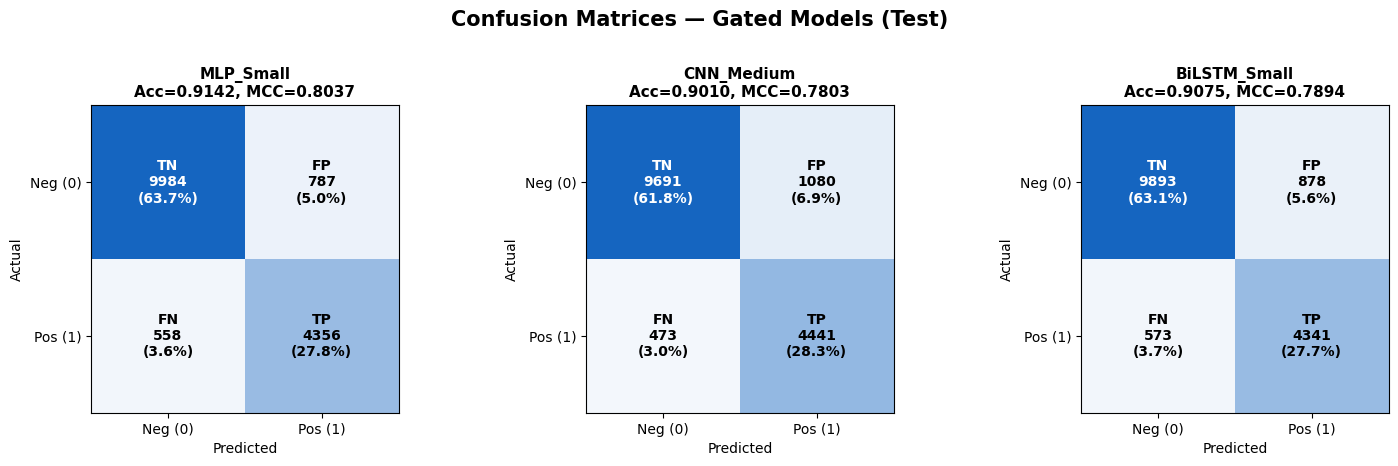

Saved: /kaggle/working/Validation_Results/confusion_matrices.png


In [24]:
n_models = len(all_eval)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)
cmap_cm = LinearSegmentedColormap.from_list("custom_blue", ["#ffffff", "#1565C0"])

for idx, r in enumerate(all_eval):
    row_i, col_i = divmod(idx, n_cols)
    ax = axes[row_i][col_i]
    cm_data = r["test_metrics"]["confusion_matrix"]
    cm = np.array([[cm_data["tn"], cm_data["fp"]],
                   [cm_data["fn"], cm_data["tp"]]])
    total = cm.sum()
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap_cm, vmin=0, vmax=cm.max())
    labels_text = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / total * 100
            color = "white" if val > cm.max() * 0.6 else "black"
            ax.text(j, i, f"{labels_text[i][j]}\n{val}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=10, color=color, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg (0)", "Pos (1)"])
    ax.set_yticklabels(["Neg (0)", "Pos (1)"])
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    acc = r["test_metrics"]["accuracy"]
    mcc = r["test_metrics"]["mcc"]
    ax.set_title(f"{r['name']}\nAcc={acc:.4f}, MCC={mcc:.4f}", fontsize=11, fontweight="bold")

for idx in range(n_models, n_rows * n_cols):
    row_i, col_i = divmod(idx, n_cols)
    axes[row_i][col_i].set_visible(False)

fig.suptitle("Confusion Matrices — Gated Models (Test)", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'confusion_matrices.png'}")

## 🎯 Visualización: Gráfico de radar multidimensional

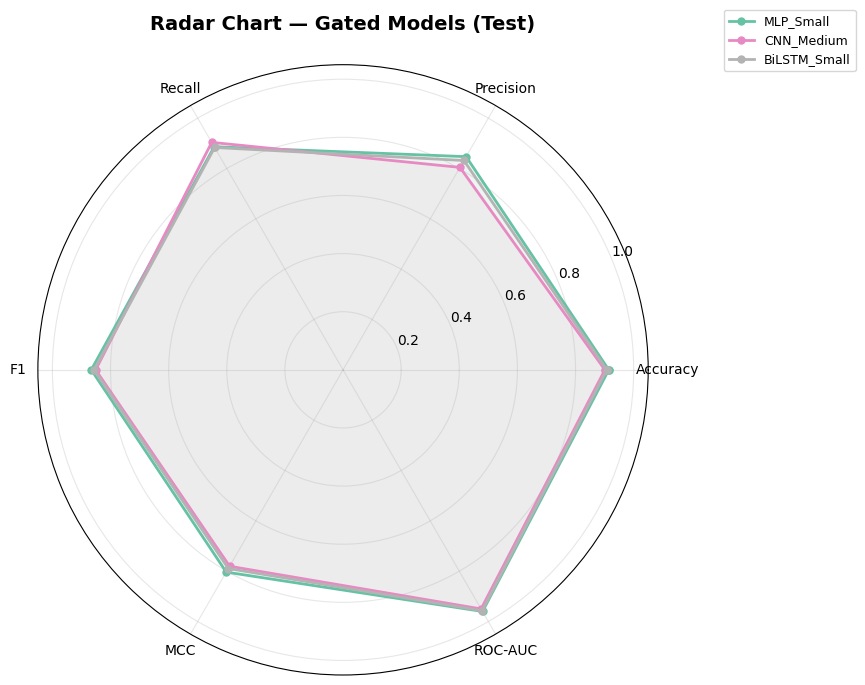

Saved: /kaggle/working/Validation_Results/radar_chart.png


In [25]:
radar_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "roc_auc"]
radar_labels = ["Accuracy", "Precision", "Recall", "F1", "MCC", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
colors_radar = plt.cm.Set2(np.linspace(0, 0.9, len(all_eval)))

for idx, r in enumerate(all_eval):
    values = [r["test_metrics"].get(m, 0) or 0 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=r["name"], color=colors_radar[idx], markersize=5)
    ax.fill(angles, values, alpha=0.08, color=colors_radar[idx])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Radar Chart — Gated Models (Test)", fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(EVAL_DIR / "radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'radar_chart.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo (Validación vs Prueba)

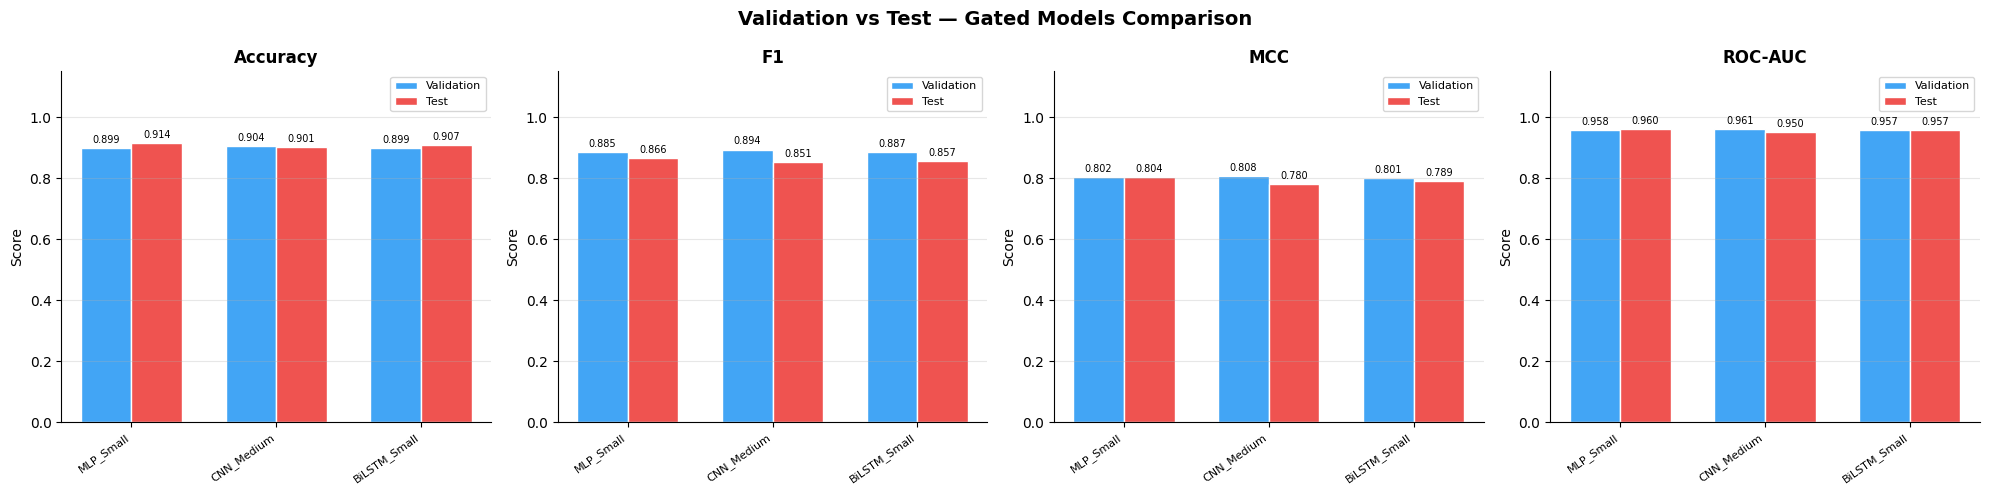

Saved: /kaggle/working/Validation_Results/val_vs_test_comparison.png


In [26]:
val_test_metrics = ["accuracy", "f1", "mcc", "roc_auc"]
val_test_labels  = ["Accuracy", "F1", "MCC", "ROC-AUC"]

fig, axes = plt.subplots(1, len(val_test_metrics), figsize=(5 * len(val_test_metrics), 5))
model_names = [r["name"] for r in all_eval]
x = np.arange(len(model_names))
width_vt = 0.35

for ax_idx, (metric_key, metric_label) in enumerate(zip(val_test_metrics, val_test_labels)):
    ax = axes[ax_idx]
    val_vals = []
    test_vals = []
    for r in all_eval:
        vm = r.get("val_metrics", {})
        tm = r["test_metrics"]
        val_vals.append(vm.get(metric_key, 0) or 0)
        test_vals.append(tm.get(metric_key, 0) or 0)

    bars1 = ax.bar(x - width_vt / 2, val_vals, width_vt, label="Validation", color="#42A5F5", edgecolor="white")
    bars2 = ax.bar(x + width_vt / 2, test_vals, width_vt, label="Test", color="#EF5350", edgecolor="white")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title(metric_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Validation vs Test — Gated Models Comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(EVAL_DIR / "val_vs_test_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {EVAL_DIR / 'val_vs_test_comparison.png'}")

## 💾 Guardado de resultados para reproducibilidad

In [27]:
all_metrics_json = {}
for r in all_eval:
    all_metrics_json[r["name"]] = {
        "config": r["config"],
        "n_params": r["n_params"],
        "best_train_epoch": r["best_epoch"],
        "best_val_loss": r["best_val_loss"],
        "val_metrics": r.get("val_metrics", {}),
        "test_metrics": {k: v for k, v in r["test_metrics"].items() if k != "confusion_matrix"},
        "test_confusion_matrix": r["test_metrics"]["confusion_matrix"],
    }

json_path = EVAL_DIR / "all_models_test_metrics.json"
with open(json_path, "w") as f:
    json.dump(all_metrics_json, f, indent=2)
print(f"\nSaved: {json_path}")


Saved: /kaggle/working/Validation_Results/all_models_test_metrics.json


## 📊 Resumen Final

In [28]:
print("\n" + "=" * 90)
print("EVALUATION SUMMARY — GATED MODELS (TEST)")
print("=" * 90)

print(f"Imbalanced test set:  {TEST_PT} ({len(test_ds.y)} samples)")
print(f"Class distribution: pos={pos}, neg={neg}, ratio=1:1")
print(f"Models evaluated:   {len(all_eval)}")
print(f"Threshold:          {THRESHOLD}")
print()

print("Final Ranking (by Test MCC):")
for idx, row in results_df.iterrows():
    print(f"  #{idx} {row['Model']:25s} | "
          f"Acc={row['Test Acc']:.4f} F1={row['Test F1']:.4f} "
          f"MCC={row['Test MCC']:.4f} AUC={row['Test ROC-AUC']:.4f} "
          f"PR-AUC={row['Test PR-AUC']:.4f}")

print(f"\n🏆 Best gated model on test: {best_name}")
bm = best_entry["test_metrics"]
print(f"   Acc={bm['accuracy']:.4f} | F1={bm['f1']:.4f} | MCC={bm['mcc']:.4f} | "
      f"AUC={bm['roc_auc']:.4f} | PR-AUC={bm['pr_auc']:.4f}")

print(f"\nOutput directory: {EVAL_DIR.resolve()}")
print("Files generated:")
for f in sorted(EVAL_DIR.glob("*")):
    size = f.stat().st_size
    print(f"  {f.name:45s} ({size / 1024:.1f} KB)")
print("=" * 90)


EVALUATION SUMMARY — GATED MODELS (TEST)
Imbalanced test set:  /kaggle/input/datasets/user/new-final-dataset/test_dataset.pt (15685 samples)
Class distribution: pos=4914, neg=10771, ratio=1:1
Models evaluated:   3
Threshold:          0.5

Final Ranking (by Test MCC):
  #1 MLP_Small                 | Acc=0.9142 F1=0.8663 MCC=0.8037 AUC=0.9600 PR-AUC=0.9445
  #2 BiLSTM_Small              | Acc=0.9075 F1=0.8568 MCC=0.7894 AUC=0.9572 PR-AUC=0.9406
  #3 CNN_Medium                | Acc=0.9010 F1=0.8512 MCC=0.7803 AUC=0.9499 PR-AUC=0.9345

🏆 Best gated model on test: MLP_Small
   Acc=0.9142 | F1=0.8663 | MCC=0.8037 | AUC=0.9600 | PR-AUC=0.9445

Output directory: /kaggle/working/Validation_Results
Files generated:
  all_models_test_metrics.json                  (2.9 KB)
  confusion_matrices.png                        (122.3 KB)
  radar_chart.png                               (263.1 KB)
  roc_curves_comparison.png                     (119.1 KB)
  test_comparison_table.csv                     (

## 🏆 Conclusión: el mejor modelo en validación externa

Tras evaluar los checkpoints en un conjunto de prueba de **15,685 muestras**, el modelo con mejor rendimiento global fue **MLP_Small**, según la métrica **Test MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | MLP_Small |
| Parámetros    | 1,125,442 |
| Mejor época de entrenamiento | 6 |
| Val loss      | 0.0479 |
| Val Accuracy  | 0.8992 |
| Val F1        | 0.8852 |
| Val MCC       | 0.8024 |
| Test Accuracy | 0.9142 |
| Test Precision | 0.8470 |
| Test Recall   | 0.8864 |
| Test F1       | 0.8663 |
| Test MCC      | 0.8037 |
| Test ROC-AUC  | 0.9600 |
| Test PR-AUC   | 0.9445 |

### Comparación final

| Modelo | Test MCC | Test ROC-AUC | Test PR-AUC | Test F1 |
|---|---:|---:|---:|---:|
| MLP_Small | **0.8037** | **0.9600** | **0.9445** | **0.8663** |
| BiLSTM_Small | 0.7894 | 0.9572 | 0.9406 | 0.8568 |
| CNN_Medium | 0.7803 | 0.9499 | 0.9345 | 0.8512 |

### Análisis

- **Generalización:** `MLP_Small` fue el modelo más estable al pasar de validación a test externo, mejorando incluso su MCC en test.
- **Robustez:** obtuvo el mejor equilibrio entre accuracy, F1, MCC y AUC, con una precisión alta y un recall sólido.
- **Eficiencia:** con **1,125,442 parámetros**, es el modelo más ligero de la comparación, ofreciendo la mejor relación rendimiento/costo.

**Estado final:** la validación externa confirma a **MLP_Small** como el modelo recomendado del pipeline **Gated Pooling + AAontology**. Los resultados quedaron exportados en `Validation_Results/`, incluyendo `test_comparison_table.csv`, `all_models_test_metrics.json` y las gráficas comparativas.